# 02 · Preparação dos Dados

**Tech Challenge Fase 1 · NPS Preditivo**

Objetivo deste notebook: conhecer a base, verificar a qualidade dos dados, tratar inconsistências e gerar a base tratada (`data/processed/nps_tratado.csv`) usada na Análise Exploratória (EDA).

Etapa do CRISP-DM: **Entendimento dos Dados + Preparação dos Dados**.

> Regra do projeto: o arquivo em `data/raw/` **nunca** é alterado. Todo tratamento fica registrado aqui e nas funções de `src/preparacao.py`.

## 1. Configuração e carga da base

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Permite importar o pacote src/ tanto a partir de notebooks/ quanto da raiz do projeto
sys.path.append(
    str(Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve())
)

from src.preparacao import (  # noqa: E402 (precisa vir depois do sys.path)
    CAMINHO_BASE_TRATADA,
    FAIXAS,
    ORDEM_NPS_CATEGORIA,
    RAIZ_PROJETO,
    ajustar_regressao_linear,
    calcular_nps,
    carregar_base_bruta,
    classificar_nps,
    criar_variaveis,
)

PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

df_bruto = carregar_base_bruta()
print(f"Base carregada: {df_bruto.shape[0]} linhas x {df_bruto.shape[1]} colunas")
df_bruto.head()

Base carregada: 2500 linhas x 19 colunas


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2. Visão geral das colunas

Separamos as colunas por **grupo de negócio**, seguindo o dicionário de dados do enunciado. Isso organiza a análise e deixa claro **em que momento da jornada** cada informação existe.

In [2]:
GRUPOS_COLUNAS = {
    "Identificação": ["customer_id", "order_id"],
    "Perfil do cliente": ["customer_age", "customer_region", "customer_tenure_months"],
    "Pedido": ["order_value", "items_quantity", "discount_value", "payment_installments"],
    "Logística": [
        "delivery_time_days",
        "delivery_delay_days",
        "freight_value",
        "delivery_attempts",
    ],
    "Atendimento": ["customer_service_contacts", "resolution_time_days", "complaints_count"],
    "Pós-compra (medidos junto/depois do NPS)": ["repeat_purchase_30d", "csat_internal_score"],
    "Alvo": ["nps_score"],
}

# Confere se o dicionário cobre todas as colunas da base
colunas_mapeadas = sum(GRUPOS_COLUNAS.values(), [])
assert set(colunas_mapeadas) == set(df_bruto.columns), "Há colunas fora do mapeamento"

pd.DataFrame(
    [
        (grupo, col, str(df_bruto[col].dtype), df_bruto[col].nunique())
        for grupo, cols in GRUPOS_COLUNAS.items()
        for col in cols
    ],
    columns=["grupo", "coluna", "tipo", "valores_distintos"],
)

,grupo,coluna,tipo,valores_distintos
0,Identificação,customer_id,int64,2500
1,Identificação,order_id,int64,2500
2,Perfil do cliente,customer_age,int64,52
3,Perfil do cliente,customer_region,str,5
4,Perfil do cliente,customer_tenure_months,int64,119
5,Pedido,order_value,float64,2457
6,Pedido,items_quantity,int64,6
7,Pedido,discount_value,float64,2050
8,Pedido,payment_installments,int64,11
9,Logística,delivery_time_days,int64,13


## 3. Qualidade dos dados: nulos, duplicados e chaves

In [3]:
print("Valores nulos por coluna:", int(df_bruto.isna().sum().sum()))
print("Linhas duplicadas:", df_bruto.duplicated().sum())
print("order_id repetidos:", df_bruto["order_id"].duplicated().sum())
print("customer_id repetidos:", df_bruto["customer_id"].duplicated().sum())

Valores nulos por coluna: 0
Linhas duplicadas: 0
order_id repetidos: 0
customer_id repetidos: 0


**Leitura:** a base está completa, sem nulos nem duplicados. Cada cliente aparece **uma única vez** (1 pedido por cliente), então não é preciso agregar pedidos por cliente.

## 4. Faixas de valores (o que é possível no mundo real?)

In [4]:
df_bruto.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


In [5]:
# Regras de domínio: valores que não deveriam existir
regras_dominio = {
    "nps_score fora de 0-10": ~df_bruto["nps_score"].between(0, 10),
    "csat_internal_score fora de 0-10": ~df_bruto["csat_internal_score"].between(0, 10),
    "idade < 18": df_bruto["customer_age"] < 18,
    "valores monetários negativos": (
        df_bruto[["order_value", "discount_value", "freight_value"]] < 0
    ).any(axis=1),
    "itens = 0": df_bruto["items_quantity"] == 0,
    "tentativas de entrega = 0": df_bruto["delivery_attempts"] == 0,
}
pd.Series(
    {regra: int(mascara.sum()) for regra, mascara in regras_dominio.items()}, name="qtd_registros"
)

nps_score fora de 0-10              0
csat_internal_score fora de 0-10    0
idade < 18                          0
valores monetários negativos        0
itens = 0                           0
tentativas de entrega = 0           0
Name: qtd_registros, dtype: int64

**Leitura:** nenhum valor impossível (nota fora da escala, valor negativo etc.).

Um detalhe importante: a `nps_score` tem **casas decimais** (ex.: 4,4 e 6,9). Na pesquisa de NPS tradicional a nota é inteira (0, 1, ..., 10). Isso muda a forma de classificar detratores, neutros e promotores (ver seção 6).

## 5. Inconsistências entre colunas

A seção 3 mostrou que a base **não tem nulos nem duplicados**. Mas um dado pode estar preenchido e mesmo assim estar **errado**. Aqui procuramos valores **logicamente impossíveis** quando comparamos uma coluna com outra.

Pelo dicionário de dados do enunciado, duas regras de negócio precisam ser verdadeiras:

1. **O atraso é uma parte do tempo total de entrega** (`delivery_time_days` é definido como "tempo total de entrega"), então `delivery_delay_days` nunca pode ser maior que `delivery_time_days`.
2. **O desconto não pode ser maior que o preço cheio do pedido.**


In [6]:
mascara_atraso_maior_prazo = df_bruto["delivery_delay_days"] > df_bruto["delivery_time_days"]
mascara_desconto_maior_valor = df_bruto["discount_value"] > df_bruto["order_value"]

print(
    f"Atraso maior que o tempo total de entrega: {mascara_atraso_maior_prazo.sum()} pedidos "
    f"({mascara_atraso_maior_prazo.mean():.1%})"
)
print(
    f"Desconto maior que o valor do pedido:      {mascara_desconto_maior_valor.sum()} pedidos "
    f"({mascara_desconto_maior_valor.mean():.1%})"
)

Atraso maior que o tempo total de entrega: 121 pedidos (4.8%)
Desconto maior que o valor do pedido:      35 pedidos (1.4%)


Exemplos de pedidos que quebram a regra 1. O pedido 50006, por exemplo, levou **4 dias no total**, mas teria atrasado **5 dias**, o que é impossível:

In [7]:
df_bruto.loc[
    mascara_atraso_maior_prazo,
    ["order_id", "delivery_time_days", "delivery_delay_days", "nps_score"],
].head()

,order_id,delivery_time_days,delivery_delay_days,nps_score
5,50006,4,5,0.9
18,50019,3,4,3.4
41,50042,2,3,1.8
46,50047,4,6,2.3
58,50059,2,3,3.1


### 5.1 Antes de corrigir: a regra 1 é mesmo a leitura certa?

O dicionário diz "tempo total de entrega", e é essa leitura (literal) que adotamos. Mas existe uma leitura alternativa em que **nenhuma linha seria inconsistente**: `delivery_time_days` seria o **prazo previsto**, e a entrega real levaria `prazo + atraso` dias. Como a decisão afeta 121 pedidos, verificamos o que os próprios dados dizem:


In [8]:
# Se o atraso fosse PARTE do tempo total, prazos maiores acomodariam atrasos maiores e as duas
# colunas andariam juntas. Se fossem independentes, o atraso médio seria igual em todo prazo.
corr_prazo_atraso = df_bruto["delivery_time_days"].corr(df_bruto["delivery_delay_days"])
print(f"Correlação entre tempo total e atraso: {corr_prazo_atraso:.3f}\n")

atraso_por_prazo = df_bruto.groupby("delivery_time_days")["delivery_delay_days"].mean().round(2)
print("Atraso médio (dias) para cada tempo total de entrega:")
print(atraso_por_prazo.to_string(), "\n")

# Na leitura literal, o "prazo prometido" implícito seria tempo total - atraso
prazo_implicito = df_bruto["delivery_time_days"] - df_bruto["delivery_delay_days"]
print(f"Pedidos com prazo prometido implícito = 0 dias: {(prazo_implicito == 0).sum()}")
print(f"Pedidos com prazo prometido implícito < 0 dias: {(prazo_implicito < 0).sum()}")

Correlação entre tempo total e atraso: -0.007

Atraso médio (dias) para cada tempo total de entrega:
delivery_time_days
2     2.21
3     2.27
4     2.20
5     2.17
6     2.17
7     2.11
8     2.18
9     2.16
10    2.15
11    2.28
12    2.28
13    1.97
14    2.25 

Pedidos com prazo prometido implícito = 0 dias: 146
Pedidos com prazo prometido implícito < 0 dias: 121


**Leitura:** as duas colunas são **independentes** (correlação ≈ 0 e atraso médio de ~2,2 dias em todos os prazos, de 2 a 14 dias). Se o atraso fosse de fato uma parte do tempo total, prazos curtos teriam atrasos menores. Além disso, na leitura literal, 146 pedidos teriam "prazo prometido" de **zero dias**, o que é tão impossível quanto os 121 com atraso maior que o prazo.

Ou seja: **as duas colunas foram geradas de forma independente**, e nenhuma das duas leituras do dicionário é 100% consistente com os dados. Diante disso:

- **Mantemos a leitura literal do dicionário** ("tempo total"), que é a definição oficial dada pelo enunciado, e tratamos os 121 casos impossíveis.
- **Registramos a leitura alternativa** como limitação. A conclusão de negócio não depende dela: nas duas leituras, o prazo tem relação praticamente nula com a nota, e o atraso é o fator nº 1 (notebook 03).
- **Os valores imputados não entram nas análises de prazo** do notebook 03: as linhas marcadas com `flag_inconsistencia_prazo` ficam de fora delas, para que o valor estimado não crie um padrão artificial.


### 5.2 Excluir, manter ou corrigir?

**Primeiro: qual das duas colunas tratar como errada?** A nota baixa desses clientes (média **2,3** contra **4,5** no resto da base, abaixo) é coerente com um atraso alto, em qualquer das duas leituras. O que decide é a **importância para o negócio**: o atraso é a informação central do problema (é o fator nº 1 da EDA). Corrigir o atraso destruiria justamente o dado que mais importa; corrigir o tempo total afeta uma variável que, como veremos, quase não se relaciona com a nota. Por isso tratamos `delivery_time_days` como a célula errada. O erro está em **uma célula** de cada linha, não na linha inteira: as outras 18 colunas do pedido estão corretas.

Há três caminhos para tratar essas 121 linhas:

| Opção | Consequência | Decisão |
|---|---|---|
| **1. Excluir as linhas inteiras** | Perderíamos o pedido todo (atraso, atendimento, nota) por causa de uma única célula errada. E esse é o grupo **mais insatisfeito** da base: a análise ficaria otimista e subestimaria o impacto do atraso. | ❌ |
| **2. Manter como está** | Qualquer análise de prazo usaria um valor que não pode ser verdadeiro. | ❌ |
| **3. Imputar:** tratar só a célula errada como "faltante" e substituí-la por uma estimativa | Mantém o pedido e as colunas corretas e corrige apenas o valor impossível. | ✅ |


In [9]:
# Nota média: pedidos inconsistentes x demais
df_bruto.groupby(mascara_atraso_maior_prazo)["nps_score"].mean().round(2).rename(
    index={False: "Pedidos consistentes", True: "Atraso > prazo total"}
)

Pedidos consistentes    4.49
Atraso > prazo total    2.26
Name: nps_score, dtype: float64

### 5.3 Dá para estimar o tempo de entrega com regressão linear?

A primeira ideia é a **imputação por regressão**: treinar uma regressão linear múltipla nos pedidos consistentes para prever `delivery_time_days` a partir das outras colunas. Antes de usar a técnica, verificamos se ela funciona, olhando o **R²** (quanto da variação as outras colunas conseguem explicar; regressão linear múltipla e R² vistos em Estatística, Aula 3).


In [10]:
pedidos_consistentes = df_bruto[~mascara_atraso_maior_prazo & ~mascara_desconto_maior_valor]

# Preditoras: tudo que é numérico, exceto IDs, o próprio alvo e as medidas de satisfação
# (usar a nota para preencher uma variável que depois vai explicar a nota seria circular)
colunas_excluidas = [
    "customer_id",
    "order_id",
    "nps_score",
    "csat_internal_score",
    "repeat_purchase_30d",
]


def r2_regressao_linear(dados: pd.DataFrame, alvo: str, excluir: list[str]) -> float:
    """R² de uma regressão linear múltipla para prever `alvo` com as demais colunas numéricas.

    Args:
        dados: Pedidos usados para ajustar a regressão.
        alvo: Coluna numérica a prever.
        excluir: Colunas que não podem ser preditoras (IDs, alvo da análise, satisfação).

    Returns:
        R² no próprio conjunto de ajuste (0 = não explica nada, 1 = explica tudo).
    """
    numericas = dados.select_dtypes("number").columns
    preditoras = [coluna for coluna in numericas if coluna not in excluir + [alvo]]
    _, r2 = ajustar_regressao_linear(dados, alvo, preditoras)
    return r2


r2_prazo = r2_regressao_linear(pedidos_consistentes, "delivery_time_days", colunas_excluidas)
r2_desconto = r2_regressao_linear(pedidos_consistentes, "discount_value", colunas_excluidas)
print(f"R² para prever delivery_time_days: {r2_prazo:.3f}")
print(f"R² para prever discount_value:     {r2_desconto:.3f}")

R² para prever delivery_time_days: 0.017
R² para prever discount_value:     0.006


**Leitura:** o R² é praticamente **zero**. As outras colunas explicam menos de 2% do tempo de entrega. A regressão devolveria quase sempre o mesmo número (a média), só que com aparência de precisão. **Não vale a pena usar.**

### 5.4 Imputação pela mediana

Quando nenhuma variável ajuda a prever o valor, a estimativa mais honesta é o **valor típico**. Usamos a **mediana** dos pedidos consistentes, que é menos sensível a outliers do que a média. Como o tempo total não pode ser menor que o atraso, aplicamos também `máximo(mediana, atraso)`.

O valor original é preservado em `delivery_time_days_original`, para dar transparência e permitir reverter.

In [11]:
mediana_tempo_entrega = pedidos_consistentes["delivery_time_days"].median()
print(f"Mediana do tempo de entrega (pedidos consistentes): {mediana_tempo_entrega:.0f} dias")

df_imputado = df_bruto.copy()
df_imputado["delivery_time_days_original"] = df_bruto["delivery_time_days"]
df_imputado.loc[mascara_atraso_maior_prazo, "delivery_time_days"] = np.maximum(
    mediana_tempo_entrega, df_bruto.loc[mascara_atraso_maior_prazo, "delivery_delay_days"]
).astype(int)

# Conferência: não pode sobrar nenhum pedido com atraso maior que o tempo total
assert (df_imputado["delivery_delay_days"] > df_imputado["delivery_time_days"]).sum() == 0
df_imputado.loc[
    mascara_atraso_maior_prazo,
    ["delivery_time_days_original", "delivery_time_days", "delivery_delay_days"],
].head()

Mediana do tempo de entrega (pedidos consistentes): 8 dias


,delivery_time_days_original,delivery_time_days,delivery_delay_days
5,4,8,5
18,3,8,4
41,2,8,3
46,4,8,6
58,2,8,3


### 5.5 Desconto maior que o valor do pedido

**O que parece errado:** no pedido 50007, o valor é **R$ 41,29** e o desconto é **R$ 99,62**. Se `order_value` fosse o preço cheio, o desconto seria maior que o próprio produto, o que quebra a regra 2.

Aqui **não é preciso imputar**. Existe uma leitura em que tudo faz sentido: `order_value` é o valor **já com desconto** (líquido, o que o cliente efetivamente pagou). O preço cheio era R$ 41,29 + R$ 99,62 = **R$ 140,91**, e o desconto foi de 71%. Com isso, o % de desconto é calculado sobre o valor bruto (`order_value + discount_value`) e todos os 35 casos ficam coerentes.


### 5.6 Outras relações entre colunas (testadas e não tratadas)

Pela mesma lógica da seção 5.1, verificamos as relações que **deveriam** valer entre as colunas de atendimento, se toda reclamação passasse pelo SAC:


In [12]:
sem_contato = df_bruto["customer_service_contacts"] == 0
regras_relacionais = {
    "reclamações > contatos com o atendimento": (
        df_bruto["complaints_count"] > df_bruto["customer_service_contacts"]
    ),
    "reclamação registrada sem nenhum contato": (df_bruto["complaints_count"] > 0) & sem_contato,
    "tempo de resolução > 0 sem nenhum contato": (df_bruto["resolution_time_days"] > 0)
    & sem_contato,
}
pd.DataFrame(
    {
        "pedidos": {regra: int(m.sum()) for regra, m in regras_relacionais.items()},
        "pct": {regra: round(m.mean() * 100, 1) for regra, m in regras_relacionais.items()},
    }
)

,pedidos,pct
reclamações > contatos com o atendimento,2428,97.1
reclamação registrada sem nenhum contato,531,21.2
tempo de resolução > 0 sem nenhum contato,511,20.4


**Leitura:** em **97% dos pedidos** há mais reclamações do que contatos com o atendimento, e 1 em cada 5 tem tempo de resolução sem nenhum contato. Se "reclamação" fosse algo registrado pelo SAC, isso seria impossível. As leituras compatíveis com os dados são: **reclamações e contatos são medidas diferentes** (ex.: reclamação em marketplace ou avaliação pública, sem passar pelo SAC), ou a base foi **gerada sinteticamente**, sem garantir as regras lógicas entre as colunas (o que as seções 5.1 e 9 também sugerem).

**Decisão:** não tratar. Nenhuma coluna é usada para **corrigir ou derivar** outra, e cada fator entra na EDA por conta própria. As análises conjuntas do notebook 03 (mapa de calor, regressão) usam a distribuição conjunta como ela está, com esta ressalva registrada: **as regras de consistência lógica entre colunas (atraso ≤ prazo, reclamações ≤ contatos) não valem nesta base**.

**Resumo das decisões da seção 5:**

| Inconsistência | Tratamento |
|---|---|
| Atraso > tempo total de entrega (121 pedidos, 4,8%) | `delivery_time_days` **imputado pela mediana** (regressão testada e descartada, R² ≈ 0). Original preservado e linha marcada com `flag_inconsistencia_prazo`. Linhas imputadas **ficam fora das análises de prazo** na EDA. Leitura alternativa do dicionário ("prazo previsto") registrada como limitação. |
| Desconto > valor do pedido (35 pedidos, 1,4%) | Mantido, com a hipótese de valor líquido. Linha marcada com `flag_inconsistencia_desconto`. |
| Reclamações > contatos (97%) e resolução sem contato (20%) | Mantido: colunas analisadas isoladamente. Registrado como limitação da base. |

**Nenhuma linha foi excluída.** Essas escolhas entram na seção de **Limitações e riscos** dos slides.


## 6. Variável alvo: `nps_score`

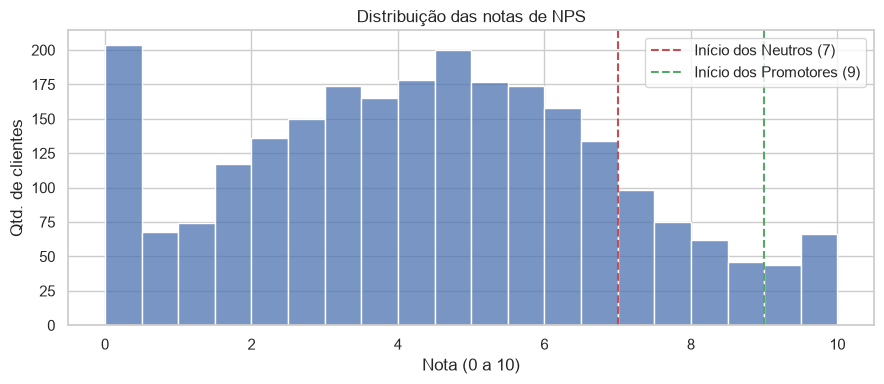

Notas entre 0.0 e 0.5: 204 clientes
Notas entre 0.5 e 1.0: 68 clientes
Notas entre 1.0 e 1.5: 74 clientes


In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df_bruto["nps_score"], bins=20, color="#4C72B0", ax=ax)
ax.axvline(7, color="#C44E52", linestyle="--", label="Início dos Neutros (7)")
ax.axvline(9, color="#55A868", linestyle="--", label="Início dos Promotores (9)")
ax.set(title="Distribuição das notas de NPS", xlabel="Nota (0 a 10)", ylabel="Qtd. de clientes")
ax.legend()
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "02_distribuicao_nps.png", dpi=150)
plt.show()

# Quantos clientes há nas três primeiras barras do histograma (0 a 1,5)?
contagens, bordas = np.histogram(df_bruto["nps_score"], bins=20, range=(0, 10))
for qtd, inicio, fim in zip(contagens[:3], bordas[:3], bordas[1:4]):
    print(f"Notas entre {inicio:.1f} e {fim:.1f}: {qtd} clientes")

**Leitura:** as notas se espalham pela escala inteira, com concentração abaixo de 7. Chama a atenção o **pico em zero**: há cerca de três vezes mais notas entre 0 e 0,5 do que nas barras vizinhas. É um **efeito de piso**: clientes muito insatisfeitos, que "dariam nota negativa" se pudessem, ficam todos travados no 0. Isso puxa a nota média para baixo, mas não muda a classificação (todos são detratores de qualquer forma), por isso privilegiamos **% de detratores** nas leituras de negócio.


### Como classificar notas com decimais?

A regra clássica do NPS é: **0 a 6 = Detrator · 7 a 8 = Neutro · 9 a 10 = Promotor**. Com decimais, há duas leituras possíveis. Comparamos as duas:

In [14]:
notas = df_bruto["nps_score"]

# Opção A (adotada): cortes diretos. Um 6,8 ainda é Detrator, porque não chegou a 7
nps_corte_direto = calcular_nps(notas)

# Opção B: arredondar a nota antes. Um 6,8 vira 7 e passa a ser Neutro
nps_arredondado = calcular_nps(notas.round())

# Só muda de categoria quem arredonda para cima e cruza um corte: notas em [6,5; 7) e [8,5; 9)
mudam_categoria = (notas.apply(classificar_nps) != notas.round().apply(classificar_nps)).sum()
print(f"NPS com corte direto (adotado): {nps_corte_direto}")
print(f"NPS arredondando as notas:      {nps_arredondado}")
print(f"Notas que mudam de categoria:   {mudam_categoria} ({mudam_categoria / len(notas):.1%})")

NPS com corte direto (adotado): -80.0
NPS arredondando as notas:      -74.1
Notas que mudam de categoria:   146 (5.8%)


**Decisão:** usamos o **corte direto** (Detrator < 7 ≤ Neutro < 9 ≤ Promotor). É a leitura mais fiel à régua do NPS, já que o cliente não chegou a dar 7. A conclusão de negócio é a mesma nas duas opções: **o NPS da empresa é fortemente negativo**.

## 7. Outliers

In [15]:
colunas_numericas = [
    "order_value",
    "discount_value",
    "freight_value",
    "delivery_time_days",
    "delivery_delay_days",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
]


def contar_outliers_iqr(serie: pd.Series) -> int:
    """Conta valores fora de [Q1 - 1,5*IQR, Q3 + 1,5*IQR], a regra clássica do boxplot."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum())


tabela_outliers = pd.DataFrame(
    {
        "qtd_outliers": {col: contar_outliers_iqr(df_bruto[col]) for col in colunas_numericas},
        "maximo": df_bruto[colunas_numericas].max(),
    }
)
tabela_outliers["pct"] = (tabela_outliers["qtd_outliers"] / len(df_bruto) * 100).round(1)
tabela_outliers

,qtd_outliers,maximo,pct
order_value,84,1983.81,3.4
discount_value,125,230.33,5.0
freight_value,12,76.13,0.5
delivery_time_days,0,14.00,0.0
delivery_delay_days,17,8.00,0.7
customer_service_contacts,176,7.00,7.0
resolution_time_days,0,11.00,0.0
complaints_count,29,11.00,1.2


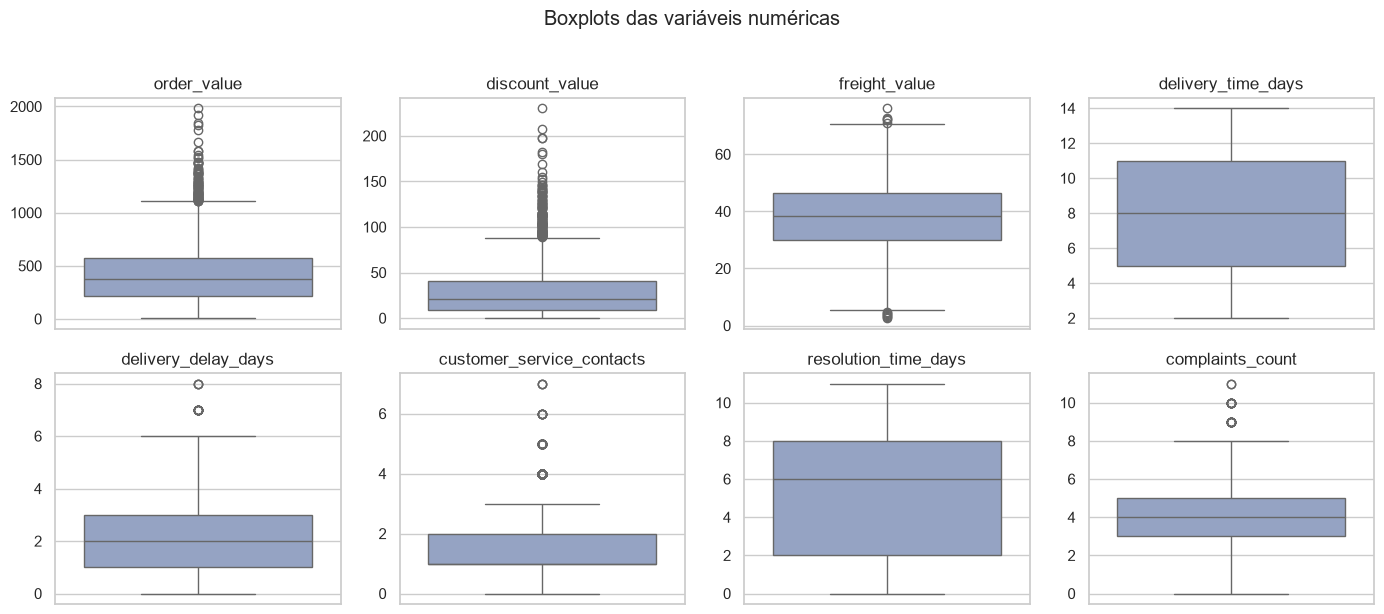

In [16]:
fig, eixos = plt.subplots(2, 4, figsize=(14, 6))
for eixo, col in zip(eixos.flat, colunas_numericas):
    sns.boxplot(y=df_bruto[col], ax=eixo, color="#8DA0CB")
    eixo.set(title=col, ylabel="")
plt.suptitle("Boxplots das variáveis numéricas", y=1.02)
plt.tight_layout()
plt.show()

**Decisão:** **manter** os outliers. São valores possíveis no negócio (um pedido grande, um cliente que ligou 7 vezes, um atraso de 8 dias) e, em geral, são justamente os casos mais relevantes para entender os detratores. Removê-los esconderia o problema.

## 8. Variáveis derivadas

Criadas em `src/preparacao.py → criar_variaveis()` para facilitar a leitura de negócio na EDA. Os cortes de todas as faixas estão em um **único lugar** (`FAIXAS`), usado tanto para criar as colunas quanto para restaurar a ordem delas ao ler o CSV:

| Variável | O que é |
|---|---|
| `nps_categoria` | Detrator / Neutro / Promotor |
| `flag_detrator` | 1 se Detrator |
| `flag_atraso` | 1 se houve qualquer atraso |
| `faixa_atraso` | Sem atraso · 1-2 dias · 3-4 dias · 5+ dias |
| `faixa_contatos` | Nenhum · 1-2 · 3+ contatos com o atendimento |
| `faixa_reclamacoes` | 0-1 · 2-3 · 4-5 · 6+ reclamações |
| `faixa_resolucao` | Até 3 dias · 4-7 dias · 8+ dias para resolver |
| `faixa_idade` | 18-29 · 30-44 · 45-59 · 60+ |
| `faixa_tempo_cliente` | Até 1 ano · 1-3 · 3-6 · 6+ anos |
| `faixa_valor_pedido` | Quartis do valor do pedido (rótulos calculados dos dados) |
| `tipo_jornada` | Perfeita (sem atraso, ≤ 1 reclamação, ≤ 1 contato) · Crítica (3+ dias de atraso **ou** 6+ reclamações **ou** 3+ contatos) · Intermediária (o resto) |
| `pct_desconto` | Desconto ÷ valor bruto do pedido |
| `pct_frete` | Frete ÷ valor do pedido |
| `flag_inconsistencia_prazo` / `flag_inconsistencia_desconto` | Marcam as inconsistências da seção 5 |
| `delivery_time_days_original` | Tempo de entrega antes da imputação |


In [17]:
df_tratado = criar_variaveis(df_imputado)  # base já com a imputação da seção 5
df_tratado["flag_inconsistencia_prazo"] = mascara_atraso_maior_prazo.astype(int)
df_tratado["flag_inconsistencia_desconto"] = mascara_desconto_maior_valor.astype(int)

df_tratado["nps_categoria"].value_counts(normalize=True).reindex(ORDEM_NPS_CATEGORIA).mul(
    100
).round(1).rename("% clientes")

nps_categoria
Detrator    84.4
Neutro      11.2
Promotor     4.4
Name: % clientes, dtype: float64

In [18]:
# Conferência: as faixas cobrem todos os registros (nenhum ficou sem faixa)
colunas_faixa = list(FAIXAS) + ["faixa_valor_pedido", "tipo_jornada"]
assert df_tratado[colunas_faixa].isna().sum().sum() == 0
df_tratado[colunas_faixa].apply(lambda s: s.value_counts().to_dict())

faixa_atraso           {'1-2 dias': 1261, '3-4 dias': 795, 'Sem atras...
faixa_contatos         {'1-2 contatos': 1456, 'Nenhum': 554, '3+ cont...
faixa_reclamacoes       {'4-5': 1044, '2-3': 784, '6+': 527, '0-1': 145}
faixa_resolucao        {'Até 3 dias': 866, '8+ dias': 842, '4-7 dias'...
faixa_idade            {'30-44': 753, '45-59': 723, '18-29': 561, '60...
faixa_tempo_cliente    {'6+ anos': 1041, '3-6 anos': 727, '1-3 anos':...
faixa_valor_pedido     {'Até R$220': 625, 'R$220-376': 625, 'R$376-57...
tipo_jornada           {'Crítica': 1358, 'Intermediária': 1065, 'Perf...
dtype: object

## 9. Atenção: colunas medidas junto ou depois do NPS

`csat_internal_score` e `repeat_purchase_30d` **não são causas** da satisfação. São **outras medidas da mesma satisfação**, coletadas junto ou depois da pesquisa de NPS:

- A recompra em 30 dias acontece **depois** do pedido. É consequência, não causa.
- O CSAT é outra pesquisa de satisfação. Explicar NPS com CSAT seria circular.

Por isso **não** entram na lista de "fatores operacionais que influenciam a satisfação" na EDA. Antes de usá-las para qualquer outra coisa (por exemplo, mostrar que "detrator não recompra"), vale a postura de desconfiar primeiro: **uma taxa de recompra de 0% entre detratores e 100% entre promotores seria boa demais para ser verdade**. Testamos:


In [19]:
print(df_bruto[["nps_score", "csat_internal_score", "repeat_purchase_30d"]].corr().round(2), "\n")

# Teste: a recompra é uma função direta da nota?
recomprou = df_bruto["repeat_purchase_30d"] == 1
menor_nota_recompra = df_bruto.loc[recomprou, "nps_score"].min()
maior_nota_sem_recompra = df_bruto.loc[~recomprou, "nps_score"].max()
nota_explica_recompra = (recomprou == (df_bruto["nps_score"] >= menor_nota_recompra)).mean()

print(f"Menor nota de quem recomprou:     {menor_nota_recompra}")
print(f"Maior nota de quem não recomprou: {maior_nota_sem_recompra}")
print(
    f"repeat_purchase_30d == (nps_score >= {menor_nota_recompra:.0f}) "
    f"em {nota_explica_recompra:.1%} das linhas\n"
)
pd.crosstab(
    df_bruto["nps_score"] >= menor_nota_recompra,
    df_bruto["repeat_purchase_30d"],
    rownames=[f"nota >= {menor_nota_recompra:.0f}"],
    colnames=["recomprou"],
)

                     nps_score  csat_internal_score  repeat_purchase_30d
nps_score                 1.00                 0.56                 0.57
csat_internal_score       0.56                 1.00                 0.34
repeat_purchase_30d       0.57                 0.34                 1.00 

Menor nota de quem recomprou:     8.0
Maior nota de quem não recomprou: 7.9
repeat_purchase_30d == (nps_score >= 8) em 100.0% das linhas



recomprou,0,1
nota >= 8,,
False,2282,0
True,0,218


**Leitura:** `repeat_purchase_30d` é **exatamente** `nps_score >= 8` em **100% das linhas**. Não existe um único cliente com nota 8 ou mais que não tenha recomprado, nem um com nota abaixo de 8 que tenha recomprado. Dado real de comportamento nunca é assim: a coluna foi **derivada da própria nota** (mais um sinal de base sintética).

**Consequências:**
- A recompra **não serve como evidência** de que "NPS gera receita": qualquer relação encontrada seria verdadeira por construção. O argumento de que satisfação gera recompra fica apoiado na literatura (Reichheld, 2003), no notebook 01.
- Fica como **alerta de qualidade** sobre a base: além das relações entre colunas não serem confiáveis (seção 5), pelo menos uma coluna foi gerada a partir do alvo.
- O CSAT (correlação 0,56 com a nota, sem ser uma função exata) é coerente com "outra medida do mesmo fenômeno" e continua fora dos fatores, como planejado.


## 10. Salvando a base tratada

In [20]:
CAMINHO_BASE_TRATADA.parent.mkdir(parents=True, exist_ok=True)
df_tratado.to_csv(CAMINHO_BASE_TRATADA, index=False)
print(f"Base tratada salva em: {CAMINHO_BASE_TRATADA.relative_to(RAIZ_PROJETO).as_posix()}")
print(
    f"{df_tratado.shape[0]} linhas x {df_tratado.shape[1]} colunas "
    f"({df_tratado.shape[1] - df_bruto.shape[1]} novas)"
)

Base tratada salva em: data/processed/nps_tratado.csv
2500 linhas x 35 colunas (16 novas)


## Resumo das decisões

1. **Base limpa:** 2.500 pedidos, sem nulos nem duplicados, 1 pedido por cliente.
2. **Nenhuma linha excluída.** Atraso > prazo (4,8%): tempo de entrega imputado pela mediana (regressão testada, R² ≈ 0); as linhas imputadas ficam fora das análises de prazo. Desconto > valor (1,4%): mantido com a hipótese de valor líquido.
3. **Regras lógicas entre colunas não valem** (prazo × atraso independentes, reclamações > contatos em 97%): nenhuma coluna é usada para corrigir ou derivar outra, e a leitura alternativa do dicionário ("prazo previsto") fica registrada como limitação.
4. **Outliers mantidos:** são casos reais e relevantes para entender detratores.
5. **Alvo:** `nps_score` classificado com corte direto (< 7 Detrator, 7 a < 9 Neutro, ≥ 9 Promotor). O pico de notas em zero é efeito de piso.
6. **CSAT e recompra** não são fatores explicativos (medidos junto ou depois do NPS). A recompra é uma **função exata da nota** (`nps_score >= 8`) e por isso não é usada nem como evidência de impacto financeiro.

➡️ Próximo passo: `03_eda.ipynb`
